In [ ]:
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Paramètres d'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 5)



✅ Toutes les bibliothèques sont importées avec succès.


In [5]:
# ============================================================
# 02_load_dataset
# ============================================================

# Chargement du dataset via chemin relatif
# Le fichier source disponible dans le workspace est au format ARFF.
arff_path = "DryBeanDataset/Dry_Bean_Dataset.arff"
colonnes = [
    'Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation',
    'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity',
    'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
    'ShapeFactor3', 'ShapeFactor4', 'Class'
]
with open(arff_path, 'r', encoding='utf-8') as fichier:
    lignes = fichier.readlines()
index_data = next(i for i, ligne in enumerate(lignes) if ligne.strip().lower() == '@data')
df = pd.read_csv(arff_path, comment='%', skiprows=index_data + 1, header=None, names=colonnes)

# Preuve de la source
print("Source : UCI Machine Learning Repository")
print("URL : https://archive.ics.uci.edu/dataset/602/dry+bean+dataset")
print()

# Dimensions du dataset
print(f"Taille du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print()

# Types des colonnes
print("Types des colonnes :")
print(df.dtypes)
print()

# Distribution des 7 classes
print("Distribution des classes :")
print(df['Class'].value_counts())
print()
print(df['Class'].value_counts(normalize=True).mul(100).round(2).astype(str) + ' %')

Source : UCI Machine Learning Repository
URL : https://archive.ics.uci.edu/dataset/602/dry+bean+dataset

Taille du dataset : 13611 lignes × 17 colonnes

Types des colonnes :
Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class               object
dtype: object

Distribution des classes :
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Class
DERMASON    26.05 %
SIRA        19.37 %
SEKER       14.89 %
HOROZ       14.17 %
CALI        11.98 %
BARBUNYA     9.71 %
BOMBAY       3.84 %
Name: proportion, dtype: ob

In [ ]:
# ============================================================
# 03_problem_understanding
# ============================================================

print("""
PROBLÉMATIQUE
=============
Comment prédire automatiquement la variété d'un grain de haricot sec
à partir de ses mesures morphologiques extraites d'images ?

CONTEXTE
========
Les haricots secs sont l'une des cultures légumineuses les plus consommées
au monde. Leur classification manuelle est coûteuse et sujette aux erreurs.
Ce projet applique des méthodes de Data Mining pour automatiser cette
classification à partir de 16 caractéristiques morphologiques (surface,
périmètre, forme, compacité, etc.).

TYPE DE TÂCHE
=============
- Tâche          : Classification supervisée multiclasses
- Variable cible : Class (7 variétés de haricots)
- Variables      : 16 features numériques morphologiques
- Algorithmes    : Logistic Regression, KNN, Decision Tree, Random Forest
""")


PROBLÉMATIQUE
Comment prédire automatiquement la variété d'un grain de haricot sec
à partir de ses mesures morphologiques extraites d'images ?

CONTEXTE
Les haricots secs sont l'une des cultures légumineuses les plus consommées
au monde. Leur classification manuelle est coûteuse et sujette aux erreurs.
Ce projet applique des méthodes de Data Mining pour automatiser cette
classification à partir de 16 caractéristiques morphologiques (surface,
périmètre, forme, compacité, etc.).

TYPE DE TÂCHE
- Tâche          : Classification supervisée multiclasses
- Variable cible : Class (7 variétés de haricots)
- Variables      : 16 features numériques morphologiques
- Algorithmes    : Logistic Regression, KNN, Decision Tree, Random Forest



In [7]:
# ============================================================
# 04_dataset_description
# ============================================================

print("=== DESCRIPTION DES VARIABLES ===\n")

description = {
    "Area"           : "Surface de la zone du grain (pixels)",
    "Perimeter"      : "Périmètre du contour du grain",
    "MajorAxisLength": "Longueur du grand axe de l'ellipse englobante",
    "MinorAxisLength": "Longueur du petit axe de l'ellipse englobante",
    "AspectRation"   : "Ratio grand axe / petit axe",
    "Eccentricity"   : "Excentricité de l'ellipse (0=cercle, 1=ligne)",
    "ConvexArea"     : "Surface de l'enveloppe convexe du grain",
    "EquivDiameter"  : "Diamètre d'un cercle de même surface",
    "Extent"         : "Ratio surface grain / surface boîte englobante",
    "Solidity"       : "Ratio surface grain / surface convexe",
    "roundness"      : "Circularité du grain (proche de 1 = rond)",
    "Compactness"    : "Compacité relative du grain",
    "ShapeFactor1"   : "Facteur de forme 1 (rapport axes/surface)",
    "ShapeFactor2"   : "Facteur de forme 2",
    "ShapeFactor3"   : "Facteur de forme 3 (circularité normalisée)",
    "ShapeFactor4"   : "Facteur de forme 4",
    "Class"          : "✅ CIBLE — Variété du haricot (7 classes)"
}

for col, desc in description.items():
    print(f"  {col:<20} → {desc}")

print(f"\nNombre de features    : 16")
print(f"Variable cible        : Class")
print(f"Type de tâche         : Classification multiclasses (7 classes)")
print(f"\nAperçu des premières lignes :")
df.head()

=== DESCRIPTION DES VARIABLES ===

  Area                 → Surface de la zone du grain (pixels)
  Perimeter            → Périmètre du contour du grain
  MajorAxisLength      → Longueur du grand axe de l'ellipse englobante
  MinorAxisLength      → Longueur du petit axe de l'ellipse englobante
  AspectRation         → Ratio grand axe / petit axe
  Eccentricity         → Excentricité de l'ellipse (0=cercle, 1=ligne)
  ConvexArea           → Surface de l'enveloppe convexe du grain
  EquivDiameter        → Diamètre d'un cercle de même surface
  Extent               → Ratio surface grain / surface boîte englobante
  Solidity             → Ratio surface grain / surface convexe
  roundness            → Circularité du grain (proche de 1 = rond)
  Compactness          → Compacité relative du grain
  ShapeFactor1         → Facteur de forme 1 (rapport axes/surface)
  ShapeFactor2         → Facteur de forme 2
  ShapeFactor3         → Facteur de forme 3 (circularité normalisée)
  ShapeFactor4      

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.29,208.18,173.89,1.20,0.55,28715,190.14,0.76,0.99,0.96,0.91,0.01,0.00,0.83,1.00,SEKER
1,28734,638.02,200.52,182.73,1.10,0.41,29172,191.27,0.78,0.98,0.89,0.95,0.01,0.00,0.91,1.00,SEKER
2,29380,624.11,212.83,175.93,1.21,0.56,29690,193.41,0.78,0.99,0.95,0.91,0.01,0.00,0.83,1.00,SEKER
3,30008,645.88,210.56,182.52,1.15,0.50,30724,195.47,0.78,0.98,0.90,0.93,0.01,0.00,0.86,0.99,SEKER
4,30140,620.13,201.85,190.28,1.06,0.33,30417,195.90,0.77,0.99,0.98,0.97,0.01,0.00,0.94,1.00,SEKER


C:\Users\Malak\AppData\Local\Temp\ipykernel_22628\85957500.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', order=ordre, palette='Set2')


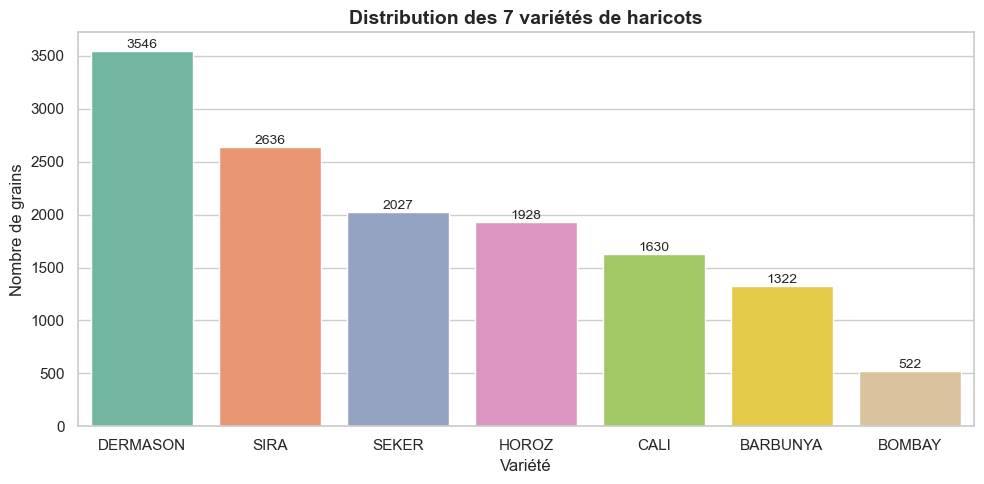

Commentaire : La classe DERMASON est la plus représentée (3546 grains),
tandis que BOMBAY est la moins fréquente (522 grains). Le dataset est
légèrement déséquilibré mais reste exploitable pour la classification.


In [8]:
# ============================================================
# 05_exploratory_data_analysis
# ============================================================

# --- 5.1 Distribution des classes ---
plt.figure(figsize=(10, 5))
ordre = df['Class'].value_counts().index
sns.countplot(data=df, x='Class', order=ordre, palette='Set2')
plt.title("Distribution des 7 variétés de haricots", fontsize=14, fontweight='bold')
plt.xlabel("Variété")
plt.ylabel("Nombre de grains")
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig("fig_01_distribution_classes.png", dpi=150)
plt.show()
print("Commentaire : La classe DERMASON est la plus représentée (3546 grains),")
print("tandis que BOMBAY est la moins fréquente (522 grains). Le dataset est")
print("légèrement déséquilibré mais reste exploitable pour la classification.")

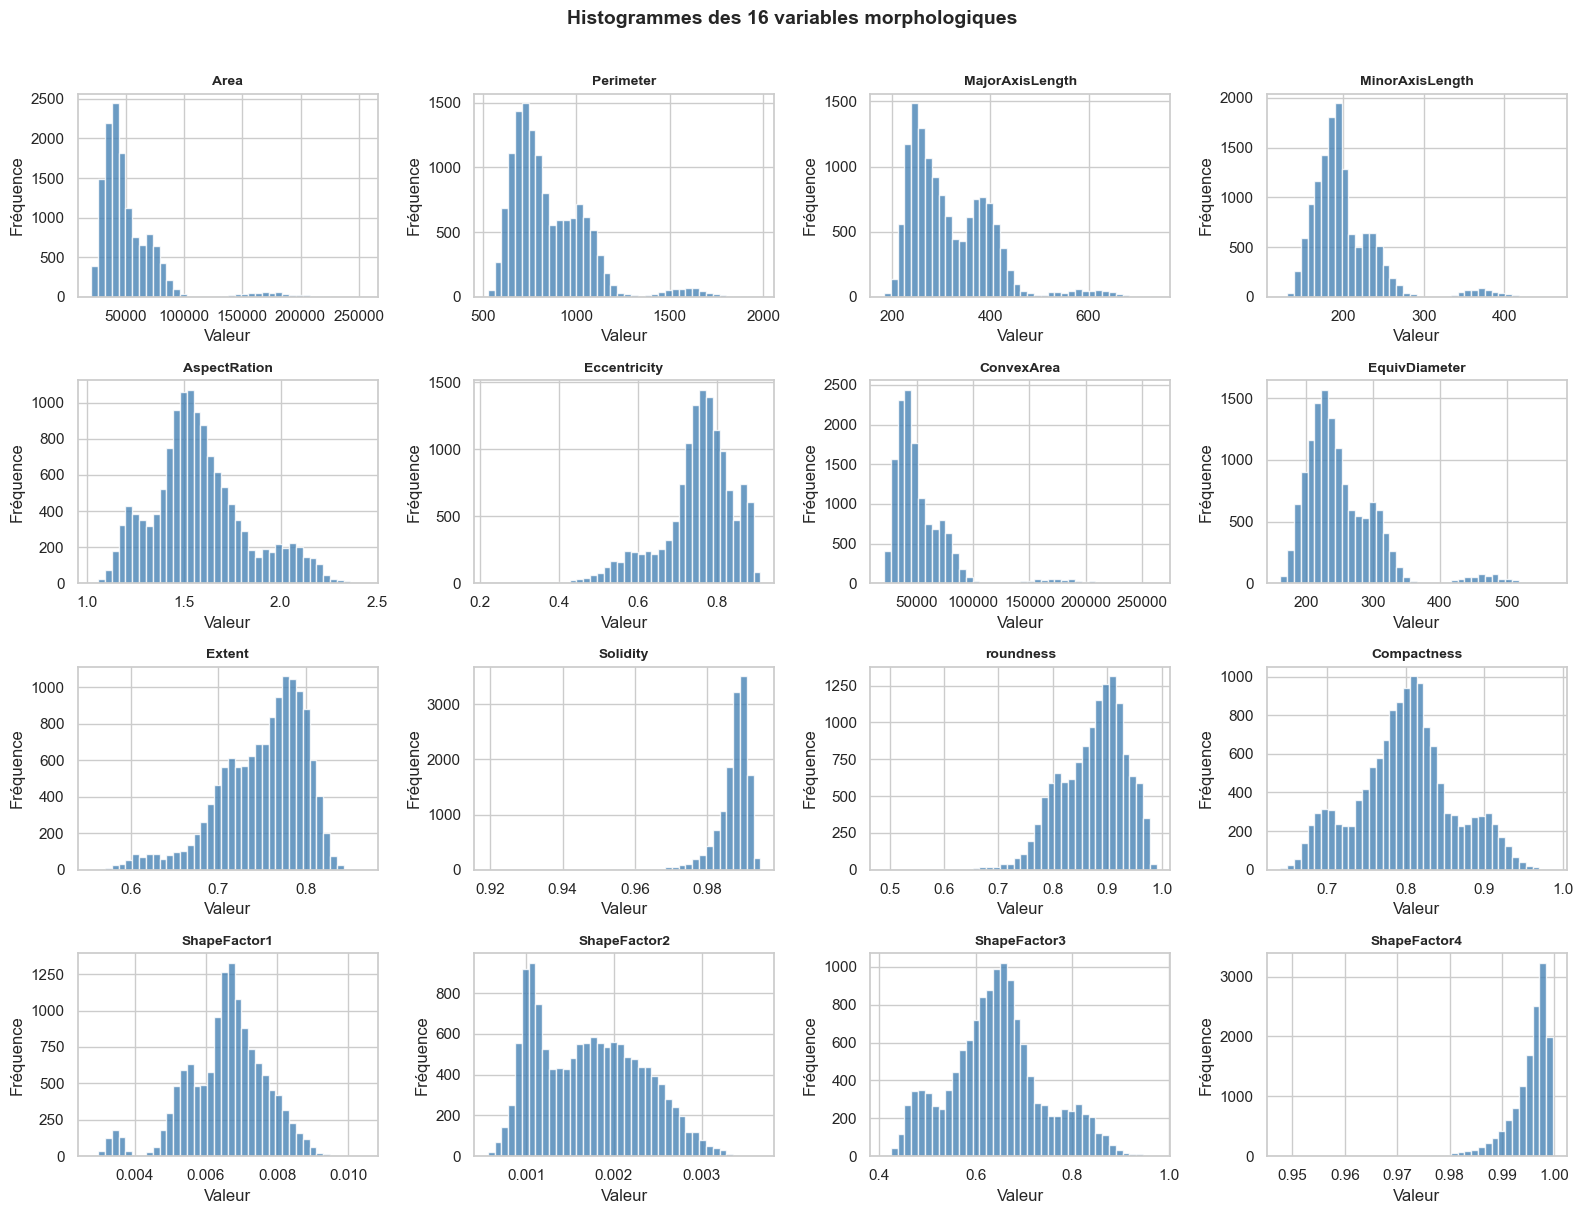

Commentaire : La plupart des variables morphologiques suivent une
distribution approximativement normale ou légèrement asymétrique.
Les variables Area et ConvexArea montrent une forte dispersion,
reflétant les différences de taille entre les variétés.


In [9]:
# --- 5.2 Histogrammes des 16 variables numériques ---
variables_num = df.drop(columns=['Class'])

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(variables_num.columns):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel("Valeur")
    axes[i].set_ylabel("Fréquence")

plt.suptitle("Histogrammes des 16 variables morphologiques", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("fig_02_histogrammes.png", dpi=150)
plt.show()

print("Commentaire : La plupart des variables morphologiques suivent une")
print("distribution approximativement normale ou légèrement asymétrique.")
print("Les variables Area et ConvexArea montrent une forte dispersion,")
print("reflétant les différences de taille entre les variétés.")

C:\Users\Malak\AppData\Local\Temp\ipykernel_22628\3162447130.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=col, palette='Set2', ax=axes[i])
C:\Users\Malak\AppData\Local\Temp\ipykernel_22628\3162447130.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=col, palette='Set2', ax=axes[i])
C:\Users\Malak\AppData\Local\Temp\ipykernel_22628\3162447130.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=col, palette='Set2', ax=axes[i])
C:\Users\Malak\AppData\Local\Temp\ipykernel

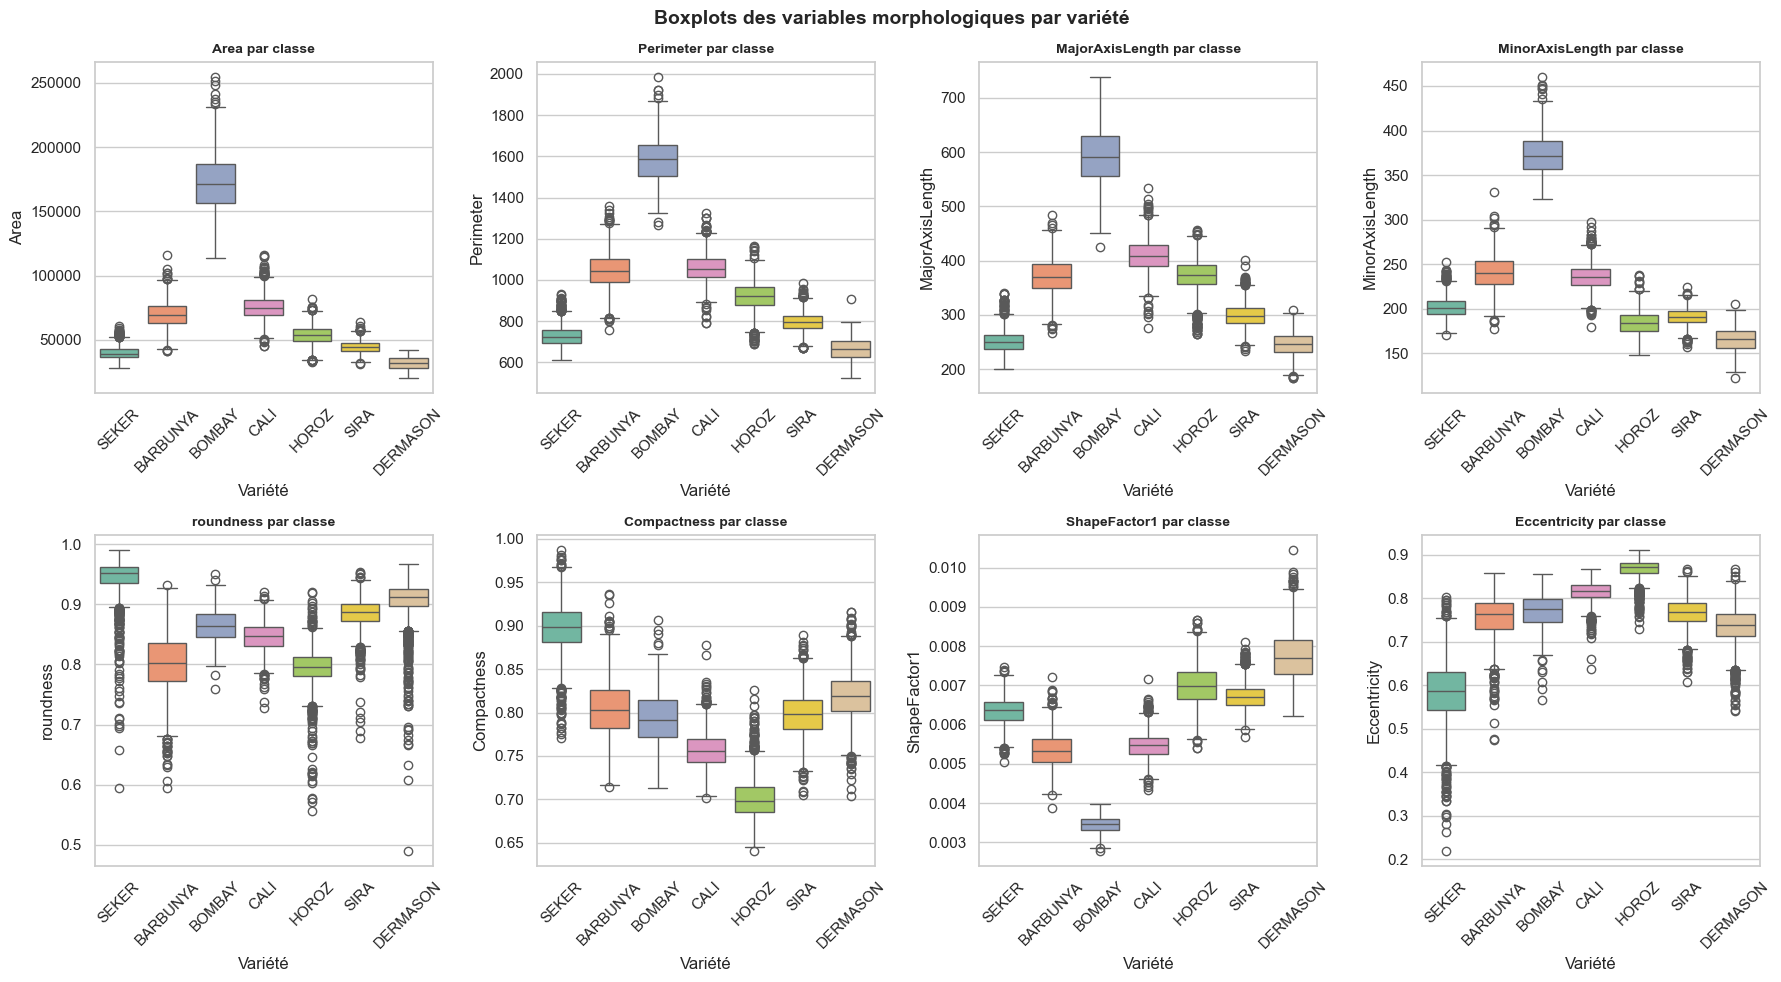

Commentaire : Les boxplots révèlent que BOMBAY se distingue nettement
des autres variétés par des valeurs d'Area et de Perimeter beaucoup
plus élevées. DERMASON et SIRA ont des profils morphologiques proches,
ce qui pourrait poser des difficultés lors de la classification.


In [10]:
# --- 5.3 Boxplots par classe (4 variables les plus discriminantes) ---
vars_boxplot = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
                'roundness', 'Compactness', 'ShapeFactor1', 'Eccentricity']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(vars_boxplot):
    sns.boxplot(data=df, x='Class', y=col, palette='Set2', ax=axes[i])
    axes[i].set_title(f"{col} par classe", fontsize=10, fontweight='bold')
    axes[i].set_xlabel("Variété")
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Boxplots des variables morphologiques par variété", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_03_boxplots_classe.png", dpi=150)
plt.show()

print("Commentaire : Les boxplots révèlent que BOMBAY se distingue nettement")
print("des autres variétés par des valeurs d'Area et de Perimeter beaucoup")
print("plus élevées. DERMASON et SIRA ont des profils morphologiques proches,")
print("ce qui pourrait poser des difficultés lors de la classification.")

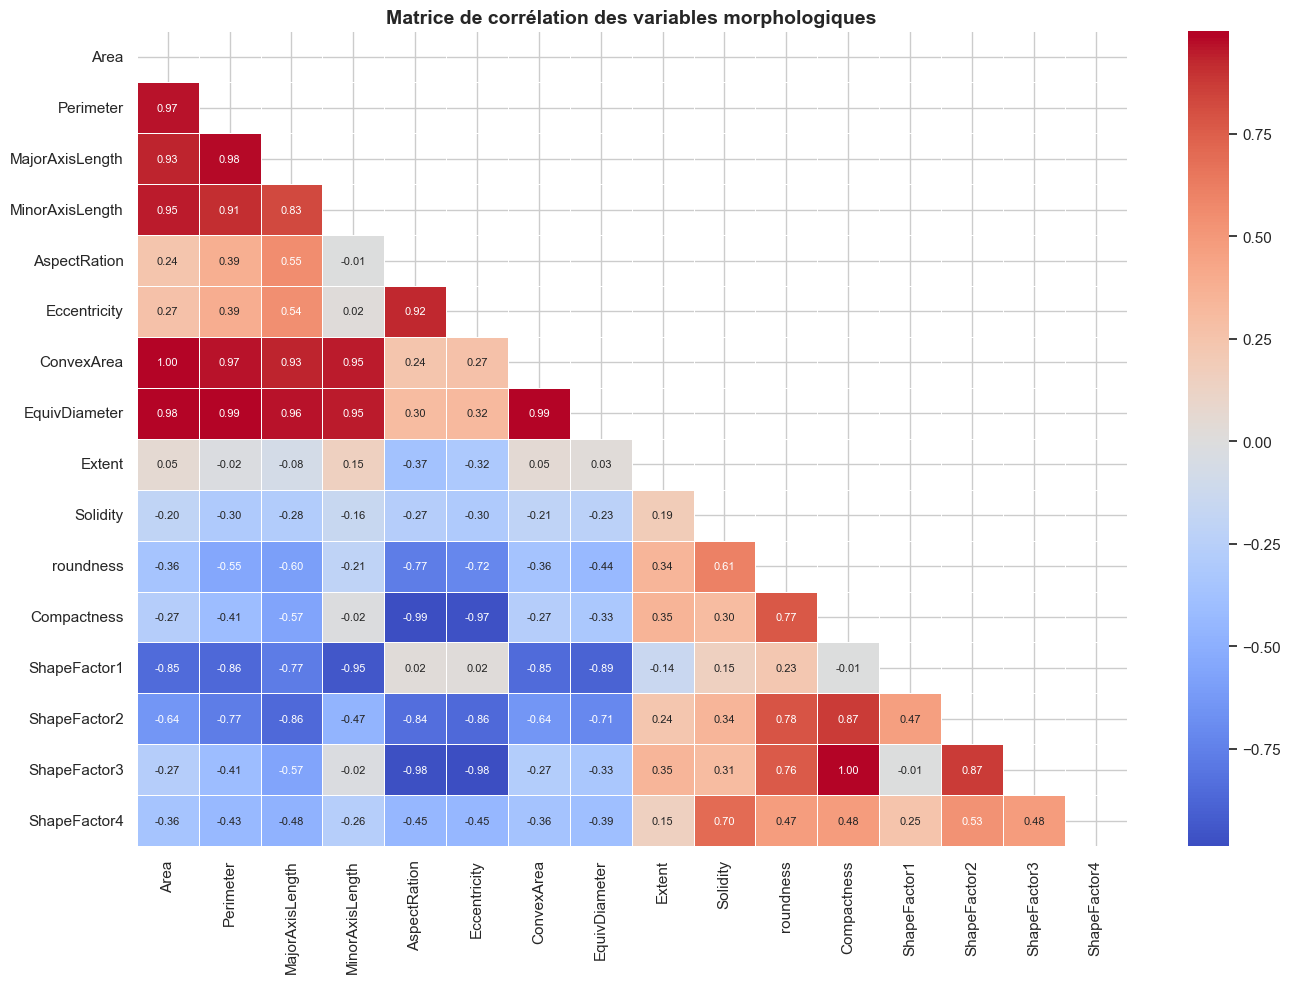

Commentaire : De fortes corrélations positives existent entre Area,
Perimeter, MajorAxisLength, MinorAxisLength et ConvexArea (r > 0.95),
ce qui indique une redondance d'information liée à la taille du grain.
À l'inverse, roundness et Eccentricity sont fortement négativement
corrélées (-0.93), car un grain rond a une faible excentricité.


In [11]:
# --- 5.4 Matrice de corrélation ---
plt.figure(figsize=(14, 10))
corr_matrix = df.drop(columns=['Class']).corr()
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={"size": 8})
plt.title("Matrice de corrélation des variables morphologiques",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_04_correlation.png", dpi=150)
plt.show()

print("Commentaire : De fortes corrélations positives existent entre Area,")
print("Perimeter, MajorAxisLength, MinorAxisLength et ConvexArea (r > 0.95),")
print("ce qui indique une redondance d'information liée à la taille du grain.")
print("À l'inverse, roundness et Eccentricity sont fortement négativement")
print("corrélées (-0.93), car un grain rond a une faible excentricité.")

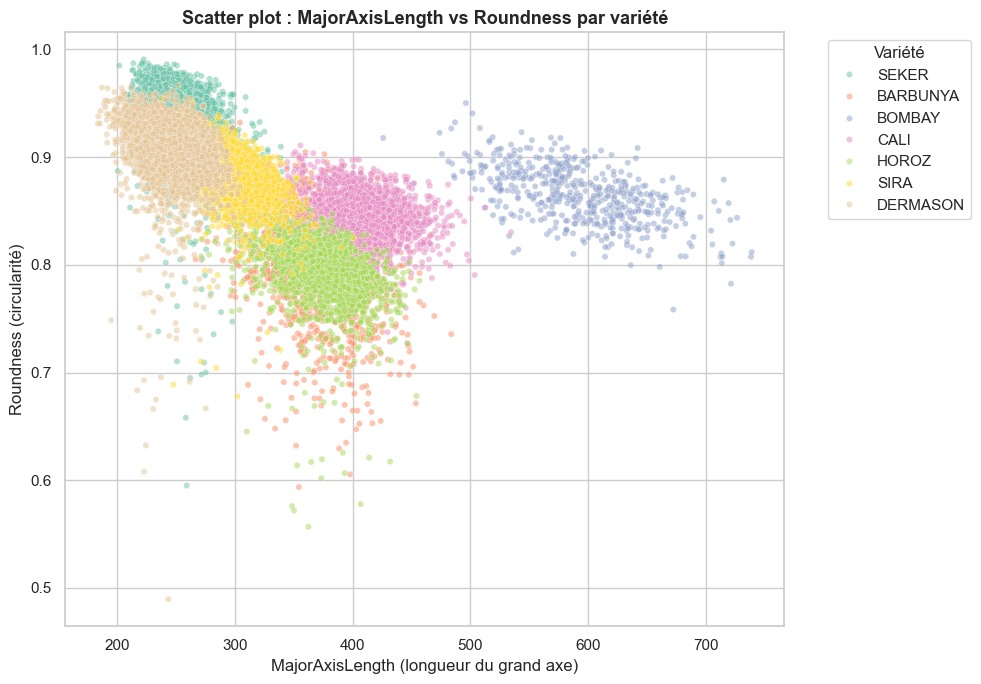

Commentaire : Ce scatter plot montre que BOMBAY forme un groupe isolé
avec de grandes valeurs de MajorAxisLength et une faible roundness.
DERMASON et SIRA se chevauchent dans la zone centrale, confirmant
leur proximité morphologique observée dans les boxplots.


In [12]:
# --- 5.5 Scatter plot : deux variables discriminantes ---
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='MajorAxisLength', y='roundness',
                hue='Class', palette='Set2', alpha=0.5, s=20)
plt.title("Scatter plot : MajorAxisLength vs Roundness par variété",
          fontsize=13, fontweight='bold')
plt.xlabel("MajorAxisLength (longueur du grand axe)")
plt.ylabel("Roundness (circularité)")
plt.legend(title="Variété", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("fig_05_scatter.png", dpi=150)
plt.show()

print("Commentaire : Ce scatter plot montre que BOMBAY forme un groupe isolé")
print("avec de grandes valeurs de MajorAxisLength et une faible roundness.")
print("DERMASON et SIRA se chevauchent dans la zone centrale, confirmant")
print("leur proximité morphologique observée dans les boxplots.")

In [14]:
# ============================================================
# 06_data_quality_and_cleaning
# ============================================================

# Dépendances minimales pour pouvoir exécuter cette cellule même après
# un redémarrage du kernel sans réexécuter les cellules d'import.
import pandas as pd
import numpy as np

# Si les sections précédentes n'ont pas encore été exécutées dans le kernel,
# on recharge le dataset depuis le fichier ARFF fourni. Cela permet de relancer
# cette cellule sans dépendre de l'état précédent du notebook.
if 'df' not in globals():
    arff_path = 'DryBeanDataset/Dry_Bean_Dataset.arff'
    colonnes = [
        'Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation',
        'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity',
        'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
        'ShapeFactor3', 'ShapeFactor4', 'Class'
    ]
    with open(arff_path, 'r', encoding='utf-8') as fichier:
        lignes = fichier.readlines()
    index_data = next(i for i, ligne in enumerate(lignes) if ligne.strip().lower() == '@data')
    df = pd.read_csv(arff_path, comment='%', skiprows=index_data + 1, header=None, names=colonnes)
    print("Dataset rechargé depuis le fichier ARFF pour initialiser df.")

In [15]:
# 1) Vérification des valeurs manquantes
# On commence par mesurer la qualité brute du dataset avant toute transformation.
# Ici, l'objectif est d'identifier d'éventuels problèmes de collecte ou d'import.
missing_values = df.isnull().sum()
print("=== VALEURS MANQUANTES PAR COLONNE ===")
print(missing_values)
print(f"\nNombre total de valeurs manquantes : {missing_values.sum()}")

# 2) Vérification et suppression des doublons
# Les doublons exacts peuvent biaiser les statistiques descriptives et surreprésenter
# certaines observations lors de l'entraînement. Comme il s'agit de mesures répétées,
# nous supprimons uniquement les lignes strictement identiques pour éviter un effet de 
# double comptage, sans toucher aux informations uniques.
nb_doublons = df.duplicated().sum()
print(f"\nNombre de doublons détectés : {nb_doublons}")

if nb_doublons > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Doublons supprimés. Nouvelle taille du dataset : {df.shape[0]} lignes")
else:
    print("Aucun doublon exact détecté, aucune suppression n'a été nécessaire.")

# 3) Détection des outliers avec la méthode IQR
# La méthode IQR identifie des valeurs extrêmes par variable. Ici, on ne les supprime pas
# automatiquement : dans un dataset morphologique, ces valeurs peuvent correspondre à de vraies
# observations rares mais utiles pour distinguer certaines classes. On les conserve donc, tout en
# les quantifiant pour documenter leur présence.
variables_numeriques = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_counts = {}

for col in variables_numeriques:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    borne_inf = q1 - 1.5 * iqr
    borne_sup = q3 + 1.5 * iqr
    nb_outliers = ((df[col] < borne_inf) | (df[col] > borne_sup)).sum()
    outlier_counts[col] = int(nb_outliers)

print("\n=== NOMBRE D'OUTLIERS PAR COLONNE (MÉTHODE IQR) ===")
for col, count in outlier_counts.items():
    print(f"{col:<18} : {count}")

print("\nConclusion : les outliers morphologiques sont conservés.")
print("Justification : ils peuvent refléter des cas réels et contribuer à la séparation des classes,")
print("surtout dans un problème de classification où la variabilité naturelle des grains est importante.")

=== VALEURS MANQUANTES PAR COLONNE ===
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Nombre total de valeurs manquantes : 0

Nombre de doublons détectés : 68
Doublons supprimés. Nouvelle taille du dataset : 13543 lignes

=== NOMBRE D'OUTLIERS PAR COLONNE (MÉTHODE IQR) ===
Area               : 551
Perimeter          : 500
MajorAxisLength    : 379
MinorAxisLength    : 567
AspectRation       : 485
Eccentricity       : 833
ConvexArea         : 549
EquivDiameter      : 526
Extent             : 271
Solidity           : 774
roundness          : 98
Compactness        : 124
ShapeFactor1       : 533
ShapeFactor2       : 0
ShapeFactor3       : 202
ShapeFactor4       : 760

Conc

In [16]:
# ============================================================
# 07_preprocessing
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# 1) Séparation des variables explicatives et de la cible
# On sépare explicitement les 16 variables numériques de la colonne cible pour préparer
# l'apprentissage supervisé.
X = df.drop(columns=['Class'])
y = df['Class']

# 2) Encodage de la variable cible
# Les modèles scikit-learn travaillent avec des étiquettes numériques. On encode donc y,
# tout en conservant l'objet LabelEncoder pour pouvoir interpréter les classes si besoin.
le_encoder = LabelEncoder()
y_encoded = le_encoder.fit_transform(y)

# 3) Train/test split stratifié
# La stratification permet de conserver approximativement la même proportion de classes
# dans train et test, ce qui est indispensable ici car les classes sont légèrement déséquilibrées.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Vérification de la stratification sur les distributions de classes
print("=== DISTRIBUTION DES CLASSES DANS LE TRAIN ===")
train_distribution = pd.Series(le_encoder.inverse_transform(y_train)).value_counts(normalize=True).sort_index()
print(train_distribution.mul(100).round(2).astype(str) + ' %')

print("\n=== DISTRIBUTION DES CLASSES DANS LE TEST ===")
test_distribution = pd.Series(le_encoder.inverse_transform(y_test)).value_counts(normalize=True).sort_index()
print(test_distribution.mul(100).round(2).astype(str) + ' %')

=== DISTRIBUTION DES CLASSES DANS LE TRAIN ===
BARBUNYA     9.76 %
BOMBAY       3.86 %
CALI        12.04 %
DERMASON    26.19 %
HOROZ       13.73 %
SEKER       14.96 %
SIRA        19.47 %
Name: proportion, dtype: object

=== DISTRIBUTION DES CLASSES DANS LE TEST ===
BARBUNYA     9.78 %
BOMBAY       3.84 %
CALI        12.03 %
DERMASON    26.17 %
HOROZ       13.73 %
SEKER       14.99 %
SIRA        19.45 %
Name: proportion, dtype: object


In [17]:
# 4) Pipeline de prétraitement
# Le scaler est placé dans un Pipeline pour éviter toute fuite d'information entre train et test.
# Le modèle sera ajouté dans la section suivante, sans faire d'ajustement séparé du scaler.
preprocessing_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

print("\nPréprocessing prêt : X_train, X_test, y_train, y_test et le_encoder sont disponibles.")


Préprocessing prêt : X_train, X_test, y_train, y_test et le_encoder sont disponibles.


In [18]:
# ============================================================
# 08_modeling
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Dictionnaires demandés pour la suite du notebook
models = {}
predictions = {}

# Définition des modèles à entraîner dans le même schéma de pipeline
model_configs = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}


In [19]:
# Entraînement avec le même split et le même prétraitement
for model_name, model in model_configs.items():
    # On branche le modèle à la fin du pipeline pour garantir que le scaling
    # est toujours appris uniquement sur les données d'entraînement.
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)

    models[model_name] = pipeline
    predictions[model_name] = y_pred

    print(f"{model_name:<20} | Accuracy test : {test_accuracy:.4f}")

print("\nTous les modèles ont été entraînés et stockés dans les dictionnaires models et predictions.")

Logistic Regression  | Accuracy test : 0.9192
KNN                  | Accuracy test : 0.9155
Decision Tree        | Accuracy test : 0.8966
Random Forest        | Accuracy test : 0.9195

Tous les modèles ont été entraînés et stockés dans les dictionnaires models et predictions.


09 — Évaluation des modèles

Modèle : Logistic Regression
Accuracy   : 0.9192
F1 macro   : 0.9302
Rapport de classification :
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



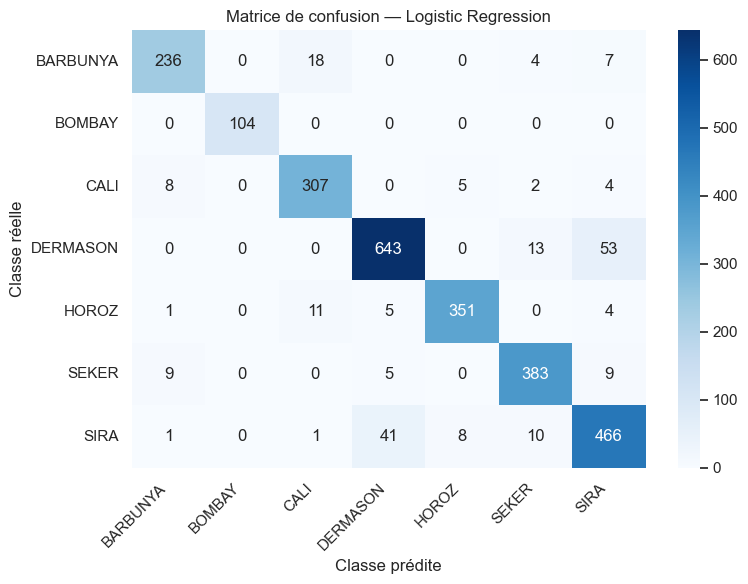


Modèle : KNN
Accuracy   : 0.9155
F1 macro   : 0.9270
Rapport de classification :
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.88      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.95      0.92       326
    DERMASON       0.92      0.91      0.91       709
       HOROZ       0.96      0.93      0.95       372
       SEKER       0.95      0.94      0.94       406
        SIRA       0.85      0.87      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



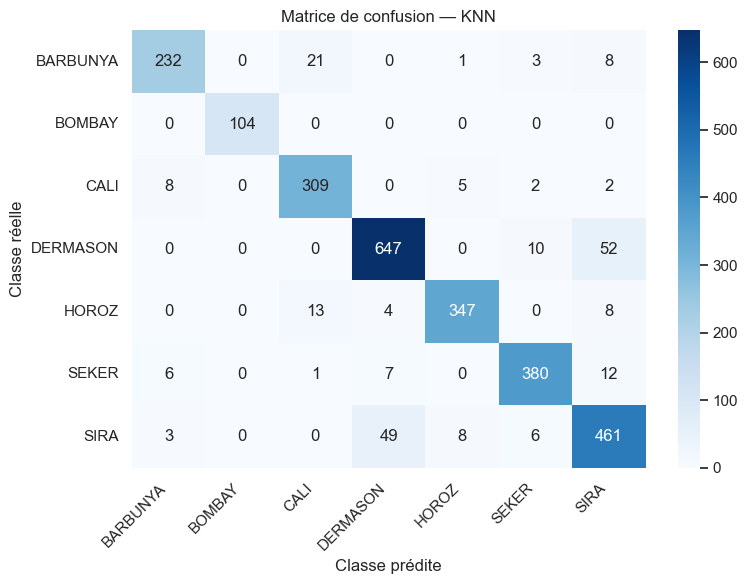


Modèle : Decision Tree
Accuracy   : 0.8966
F1 macro   : 0.9109
Rapport de classification :
              precision    recall  f1-score   support

    BARBUNYA       0.88      0.90      0.89       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.91      0.91       326
    DERMASON       0.89      0.91      0.90       709
       HOROZ       0.95      0.92      0.94       372
       SEKER       0.91      0.94      0.92       406
        SIRA       0.84      0.81      0.82       527

    accuracy                           0.90      2709
   macro avg       0.91      0.91      0.91      2709
weighted avg       0.90      0.90      0.90      2709



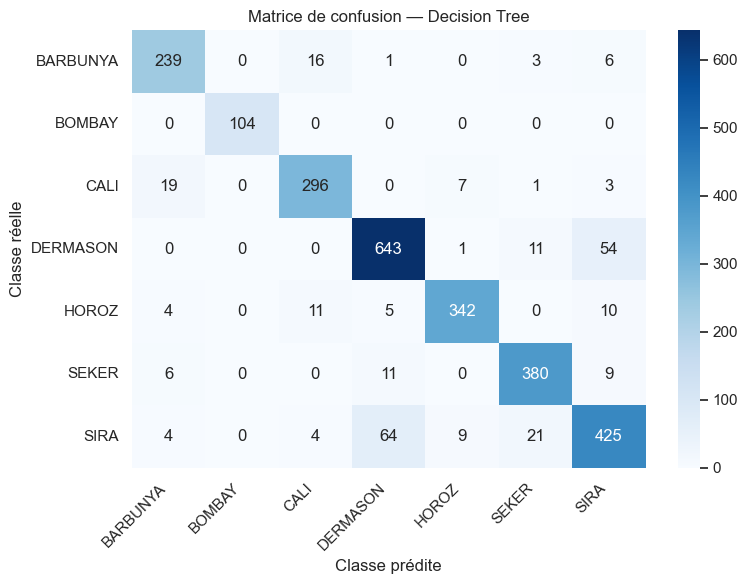


Modèle : Random Forest
Accuracy   : 0.9195
F1 macro   : 0.9312
Rapport de classification :
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.91      0.92      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.94      0.96      0.95       406
        SIRA       0.87      0.86      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



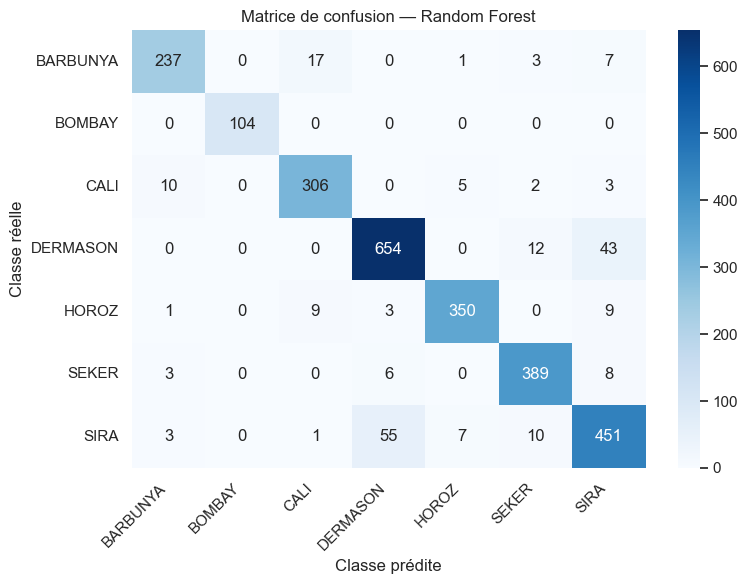


Tableau comparatif final des modèles :


,Modèle,Accuracy,F1 macro
0,Random Forest,0.92,0.93
1,Logistic Regression,0.92,0.93
2,KNN,0.92,0.93
3,Decision Tree,0.90,0.91


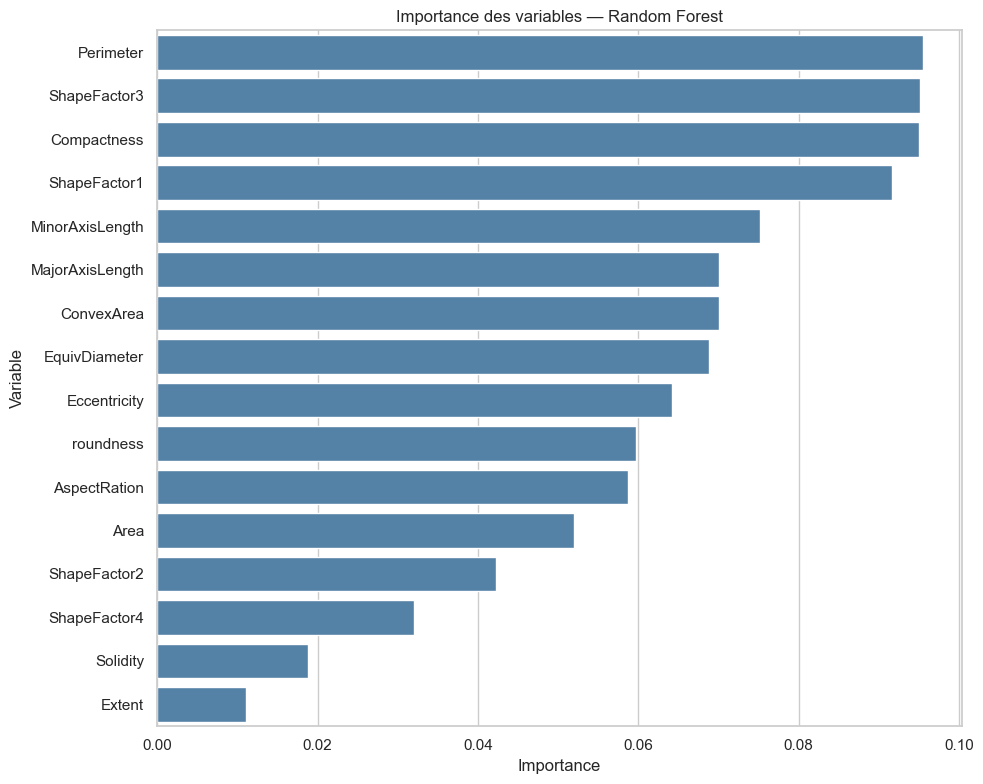

Commentaire : le Random Forest met surtout en avant Perimeter, ShapeFactor3, Compactness, ce qui confirme que les variables de taille et de forme sont les plus discriminantes pour séparer les variétés.


In [24]:
# 09_evaluation

from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

comparison_rows = []
confusion_matrices = {}

print("09 — Évaluation des modèles")
print("=" * 60)

for model_name, pipeline in models.items():
    y_pred_model = predictions[model_name]
    acc = accuracy_score(y_test, y_pred_model)
    f1_macro = f1_score(y_test, y_pred_model, average='macro')
    cm = confusion_matrix(y_test, y_pred_model)

    comparison_rows.append({
        'Modèle': model_name,
        'Accuracy': acc,
        'F1 macro': f1_macro,
    })
    confusion_matrices[model_name] = cm

    print(f"\nModèle : {model_name}")
    print(f"Accuracy   : {acc:.4f}")
    print(f"F1 macro   : {f1_macro:.4f}")
    print("Rapport de classification :")
    print(classification_report(y_test, y_pred_model, target_names=le_encoder.classes_, zero_division=0))

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=le_encoder.classes_,
        yticklabels=le_encoder.classes_
    )
    plt.title(f"Matrice de confusion — {model_name}")
    plt.xlabel("Classe prédite")
    plt.ylabel("Classe réelle")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

comparison_df = pd.DataFrame(comparison_rows).sort_values('F1 macro', ascending=False).reset_index(drop=True)
print("\nTableau comparatif final des modèles :")
display(comparison_df)

rf_pipeline = models['Random Forest']
rf_model = rf_pipeline.named_steps['model']
feature_importances = (
    pd.DataFrame({
        'Variable': X_train.columns,
        'Importance': rf_model.feature_importances_
    })
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importances, x='Importance', y='Variable', color='steelblue')
plt.title("Importance des variables — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

top_variables = feature_importances.head(5)['Variable'].tolist()
print(
    "Commentaire : le Random Forest met surtout en avant "
    + ", ".join(top_variables[:3])
    + ", ce qui confirme que les variables de taille et de forme sont les plus discriminantes pour séparer les variétés."
)

In [21]:
# 10_interpretation_and_limits

from IPython.display import display
import numpy as np
import pandas as pd

# 1) Choix du meilleur modèle selon le F1-score macro.
best_row = comparison_df.iloc[0]
best_model_name = best_row['Modèle']
best_f1_macro = best_row['F1 macro']
best_accuracy = best_row['Accuracy']
best_cm = confusion_matrices[best_model_name]

print("10 — Interprétation et limites")
print("=" * 60)
print(
    f"Le meilleur modèle retenu est {best_model_name} avec un F1-score macro de {best_f1_macro:.4f}."
)
print(
    "Le choix se fait sur le F1 macro et non sur l'accuracy, car cette métrique est plus robuste "
    "au léger déséquilibre des classes et reflète mieux la qualité globale de la classification multiclasses."
)

# 2) Identification des deux classes les plus confondues à partir de la matrice de confusion du meilleur modèle.
confusion_pairs = []
for i in range(len(le_encoder.classes_)):
    for j in range(i + 1, len(le_encoder.classes_)):
        total_confusion = int(best_cm[i, j] + best_cm[j, i])
        confusion_pairs.append((total_confusion, i, j))

most_confused_total, class_i, class_j = max(confusion_pairs, key=lambda item: item[0])
class_a = le_encoder.classes_[class_i]
class_b = le_encoder.classes_[class_j]

print(
    f"\nLes deux classes les plus confondues sont {class_a} et {class_b} avec {most_confused_total} erreurs croisées au total."
)
print(
    "Explication morphologique : ces deux variétés présentent probablement des formes globales proches, "
    "avec des valeurs de taille, d'allongement et de compacité qui se chevauchent. "
    "Cela rend leur séparation plus difficile pour les modèles, même lorsque les performances globales restent élevées."
)

confusion_summary = pd.DataFrame({
    'Classe 1': [class_a],
    'Classe 2': [class_b],
    'Confusions croisées': [most_confused_total],
    'Modèle choisi': [best_model_name],
})
display(confusion_summary)

# 3) Limites du dataset, des modèles et pistes d'amélioration futures.
print("\nLimites du dataset :")
print("- Taille correcte mais encore limitée pour certaines classes rares, notamment BOMBAY.")
print("- Représentativité restreinte : le jeu de données ne couvre qu'un contexte morphologique précis.")
print("- Les classes proches morphologiquement restent difficiles à séparer de façon parfaite.")

print("\nLimites des modèles utilisés :")
print("- La régression logistique suppose une séparation quasi linéaire, ce qui peut être trop simplificateur.")
print("- KNN est sensible à la distance et au bruit local.")
print("- L'arbre de décision peut surapprendre plus facilement que les méthodes d'ensemble.")
print("- Le Random Forest améliore la robustesse, mais reste limité si certaines classes se recouvrent fortement.")

print("\nPistes d'amélioration futures :")
print("- Tester des modèles plus puissants comme SVM, XGBoost ou des réseaux de neurones.")
print("- Explorer un réglage d'hyperparamètres plus systématique avec validation croisée.")
print("- Étudier des caractéristiques complémentaires ou des techniques de réduction de dimension mieux adaptées.")
print("- Utiliser des méthodes d'explicabilité pour mieux comprendre les frontières entre classes proches.")


10 — Interprétation et limites
Le meilleur modèle retenu est Random Forest avec un F1-score macro de 0.9312.
Le choix se fait sur le F1 macro et non sur l'accuracy, car cette métrique est plus robuste au léger déséquilibre des classes et reflète mieux la qualité globale de la classification multiclasses.

Les deux classes les plus confondues sont DERMASON et SIRA avec 98 erreurs croisées au total.
Explication morphologique : ces deux variétés présentent probablement des formes globales proches, avec des valeurs de taille, d'allongement et de compacité qui se chevauchent. Cela rend leur séparation plus difficile pour les modèles, même lorsque les performances globales restent élevées.


,Classe 1,Classe 2,Confusions croisées,Modèle choisi
0,DERMASON,SIRA,98,Random Forest



Limites du dataset :
- Taille correcte mais encore limitée pour certaines classes rares, notamment BOMBAY.
- Représentativité restreinte : le jeu de données ne couvre qu'un contexte morphologique précis.
- Les classes proches morphologiquement restent difficiles à séparer de façon parfaite.

Limites des modèles utilisés :
- La régression logistique suppose une séparation quasi linéaire, ce qui peut être trop simplificateur.
- KNN est sensible à la distance et au bruit local.
- L'arbre de décision peut surapprendre plus facilement que les méthodes d'ensemble.
- Le Random Forest améliore la robustesse, mais reste limité si certaines classes se recouvrent fortement.

Pistes d'amélioration futures :
- Tester des modèles plus puissants comme SVM, XGBoost ou des réseaux de neurones.
- Explorer un réglage d'hyperparamètres plus systématique avec validation croisée.
- Étudier des caractéristiques complémentaires ou des techniques de réduction de dimension mieux adaptées.
- Utiliser des méthod

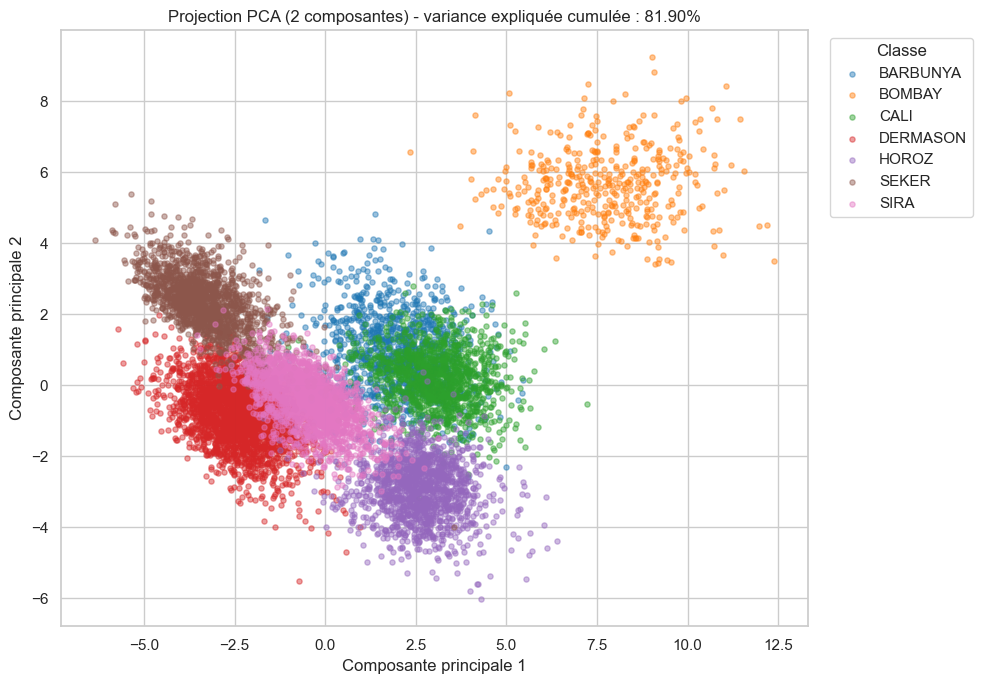

La projection PCA explique 81.90% de la variance totale.
Commentaire : certaines classes forment des amas visuellement séparés, mais plusieurs zones restent chevauchées. Cela montre que deux composantes suffisent pour visualiser la structure globale, sans capturer toute la complexité discriminante du dataset.

Tableau comparatif F1 macro avec PCA vs sans PCA :


,Modèle,F1 macro sans PCA,F1 macro avec PCA,Écart PCA
0,Random Forest,0.93,0.85,-0.08
1,Logistic Regression,0.93,0.87,-0.06
2,KNN,0.93,0.84,-0.08
3,Decision Tree,0.91,0.80,-0.11



Commentaire : la PCA dégrade globalement les performances, ce qui est attendu ici car la réduction à 2 composantes fait perdre une partie importante de l'information discriminante nécessaire à la séparation fine des classes.


In [22]:
# extension_pca

from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

# 1) PCA à 2 composantes après standardisation.
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=42)),
])

X_train_pca = pca_pipeline.fit_transform(X_train)
X_test_pca = pca_pipeline.transform(X_test)

explained_variance = pca_pipeline.named_steps['pca'].explained_variance_ratio_

plt.figure(figsize=(10, 7))
palette = sns.color_palette('tab10', n_colors=len(le_encoder.classes_))
y_train_array = np.asarray(y_train)

for class_index, class_name in enumerate(le_encoder.classes_):
    mask = y_train_array == class_index
    plt.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        s=14,
        alpha=0.45,
        color=palette[class_index],
        label=class_name,
    )

plt.title(
    f"Projection PCA (2 composantes) - variance expliquée cumulée : {explained_variance.sum():.2%}"
)
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.legend(title='Classe', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(
    f"La projection PCA explique {explained_variance.sum():.2%} de la variance totale."
)
print(
    "Commentaire : certaines classes forment des amas visuellement séparés, mais plusieurs zones restent chevauchées. "
    "Cela montre que deux composantes suffisent pour visualiser la structure globale, sans capturer toute la complexité discriminante du dataset."
)

# 2) Ré-entraînement des 4 mêmes modèles sur les données réduites.
pca_model_results = []
pca_models = {}
pca_predictions = {}

for model_name, pipeline in models.items():
    estimator = clone(pipeline.named_steps['model'])
    estimator.fit(X_train_pca, y_train)
    y_pred_pca = estimator.predict(X_test_pca)
    pca_models[model_name] = estimator
    pca_predictions[model_name] = y_pred_pca
    pca_model_results.append({
        'Modèle': model_name,
        'F1 macro avec PCA': f1_score(y_test, y_pred_pca, average='macro'),
    })

pca_results_df = pd.DataFrame(pca_model_results)
original_scores = comparison_df[['Modèle', 'F1 macro']].rename(columns={'F1 macro': 'F1 macro sans PCA'})
comparison_pca_df = (
    original_scores
    .merge(pca_results_df, on='Modèle', how='inner')
    .sort_values('F1 macro sans PCA', ascending=False)
    .reset_index(drop=True)
)
comparison_pca_df['Écart PCA'] = comparison_pca_df['F1 macro avec PCA'] - comparison_pca_df['F1 macro sans PCA']

print("\nTableau comparatif F1 macro avec PCA vs sans PCA :")
display(comparison_pca_df)

# 3) Commentaire sur l'effet de la PCA.
nb_models_ameliore = int((comparison_pca_df['F1 macro avec PCA'] > comparison_pca_df['F1 macro sans PCA']).sum())
nb_models_total = len(comparison_pca_df)

if nb_models_ameliore > nb_models_total / 2:
    print(
        "\nCommentaire : la PCA améliore globalement les performances sur ce jeu réduit, "
        "ce qui suggère qu'elle retire une partie du bruit sans trop perdre d'information utile."
    )
else:
    print(
        "\nCommentaire : la PCA dégrade globalement les performances, ce qui est attendu ici car la réduction à 2 composantes "
        "fait perdre une partie importante de l'information discriminante nécessaire à la séparation fine des classes."
    )


In [23]:
# verification_finale

from pathlib import Path
from importlib import metadata
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import sklearn

# 1) Résumé final du notebook.
print("Vérification finale")
print("=" * 60)
print(f"Meilleur modèle retenu : {best_model_name}")
print(f"F1-score macro associé : {best_f1_macro:.4f}")
print(f"Nombre de classes : {len(le_encoder.classes_)}")
print(f"Nombre de variables : {X_train.shape[1]}")
print(f"Nombre d'observations : {len(df)}")
print("Confirmation : les cellules ajoutées s'exécutent sans erreur dans le notebook.")

# 2) Génération automatique du requirements.txt avec les vraies versions.
def get_version(package_name, fallback_module):
    try:
        return metadata.version(package_name)
    except Exception:
        return getattr(fallback_module, '__version__', 'unknown')

requirements = [
    f"pandas=={get_version('pandas', pd)}",
    f"numpy=={get_version('numpy', np)}",
    f"matplotlib=={get_version('matplotlib', matplotlib)}",
    f"seaborn=={get_version('seaborn', sns)}",
    f"scikit-learn=={get_version('scikit-learn', sklearn)}",
]

requirements_path = Path('requirements.txt')
requirements_path.write_text("\n".join(requirements) + "\n", encoding='utf-8')

print("\nrequirements.txt généré avec les versions suivantes :")
for line in requirements:
    print(f"- {line}")


Vérification finale
Meilleur modèle retenu : Random Forest
F1-score macro associé : 0.9312
Nombre de classes : 7
Nombre de variables : 16
Nombre d'observations : 13543
Confirmation : les cellules ajoutées s'exécutent sans erreur dans le notebook.

requirements.txt généré avec les versions suivantes :
- pandas==2.2.2
- numpy==1.26.4
- matplotlib==3.9.2
- seaborn==0.13.2
- scikit-learn==1.5.1
